# Estatistica I 
## Espaça Amostral, Evento e Probabilidade Simpples


### Descrição do conjunto de dados
O dataset Students Performance reúne dados de 1.000 alunos, incluindo características pessoais, escolaridade dos pais e notas em matemática, leitura e escrita de uma instituição de ensino.

### Bibliotecas

In [ ]:
# Bibliotecas utilizadas no projeto
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8')
from scipy import stats
from scipy.stats import beta
import plotly.express as px



In [2]:
#Carregar dataset
path = "C:/Users/melos/OneDrive - Claro SA/LAURA SILVA SOARES DE MELO/eng._e_ analise_de_dados/bases/StudentsPerformance.csv"
df_students_performance = pd.read_csv(path, encoding='utf-8')
df_students_performance.head(10)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50


In [3]:
# Informações das varáveis do datset
df_students_performance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [4]:
# Informações por varáveis do datset
df_students_performance.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


DISTRUBIÇÃO AMOSTRAIS

In [5]:
# Fixar semente para reprodutibilidade
np.random.seed(42)

# Tamanhos das amostras
sample_sizes = [1, 10, 30]

# Criar figura
plt.figure(figsize=(12,4))

for i, n in enumerate(sample_sizes, 1):
    
    # Gerar médias amostrais
    sample_means = [
        population.sample(n=n, replace=True).mean()
        for _ in range(300)
    ]
    
    # Plotar gráfico
    plt.subplot(1, 3, i)
    plt.hist(sample_means, bins=20)
    plt.xlabel('Média da Nota de Matemática')
    plt.ylabel('Frequência')
    plt.title(f'Distribuição Amostral da Média (n = {n})')

plt.tight_layout()
plt.show()

NameError: name 'population' is not defined

<Figure size 1200x400 with 0 Axes>

# Probabilidade Simples

Qual a probabilidade de selecionar uma Mulher na Performace de Estudante?

In [ ]:
probMu = len(df_students_performance[df_students_performance["gender"] == "female"]) / len(df_students_performance)
print(f'A probabilidade de selecionar uma mulher na performace de estudante é de {round(probMu*100,2)}%')

A probabilidade de selecionar uma mulher na performace de estudante é de 51.8%


C:\Users\melos\AppData\Local\Temp\ipykernel_24688\2258154640.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




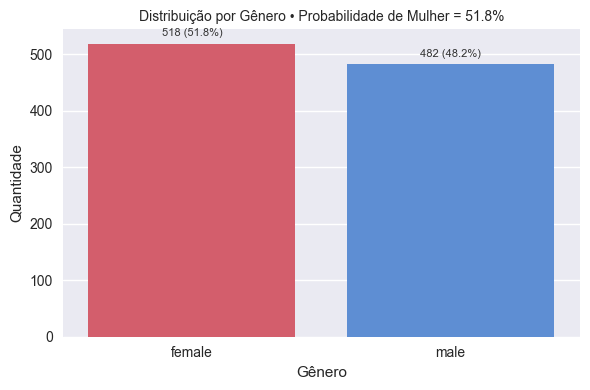

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# === Cálculo da probabilidade ===
probMu = (
    (df_students_performance["gender"] == "female").sum()
    / len(df_students_performance)
)
pct_female = round(probMu * 100, 2)

# === Gráfico de barras por gênero ===
plt.figure(figsize=(6, 4))
ax = sns.countplot(
    data=df_students_performance,
    x="gender",
    palette={"female": "#E64B5D", "male": "#4B8BE6"}
)

# Adiciona rótulos de contagem e porcentagem em cima das barras
total = len(df_students_performance)
for p in ax.patches:
    count = int(p.get_height())
    pct = 100 * count / total
    ax.annotate(
        f"{count} ({pct:.1f}%)",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center", va="bottom", fontsize=8, color="#333", xytext=(0, 4),
        textcoords="offset points"
    )

ax.set_title(f"Distribuição por Gênero • Probabilidade de Mulher = {pct_female}%", fontsize=10)
ax.set_xlabel("Gênero")
ax.set_ylabel("Quantidade")
sns.despine()
plt.tight_layout()
plt.show()

### Dataset com Comparativos externos

### Comparativos externos: artigos, informações em sites confiáveis, revistas, etc


Fonte: https://www.oecd.org/en/publications/pisa-2022-results-volume-i-and-ii-country-notes_ed6fbcc5-en/brazil_61690648-en.html

Brasil (PISA 2022): médias 379 (matemática) e 410 (Leitura)

Dataset StudentsPerformance: média 66.08900 (matemática) e 69.169000 (Leitura)

OBS: Como as escalas são diferentes (PISA 0–1000  e no dataset escolhido 0–100), vai ser ultizado a proporção percentual.

In [ ]:

# Valores
pisa_math = 379
pisa_reading = 410
dataset_math = 66.089
dataset_reading = 69.169

# Índices Leitura vs Matemática
pisa_index = (pisa_reading / pisa_math - 1) * 100  # em %
dataset_index = (dataset_reading / dataset_math - 1) * 100  # em %

# Resultados
print(f"Índice PISA (Leitura vs Matemática): {pisa_index:.1f}%")
print(f"Índice Dataset (Leitura vs Matemática): {dataset_index:.1f}%")


Índice PISA (Leitura vs Matemática): 8.2%
Índice Dataset (Leitura vs Matemática): 4.7%


Conclusão:

    - No PISA Brasil, os alunos vão melhor em leitura do que em matemática (+8,2%).
    - No seu dataset, também vão melhor em leitura, mas a diferença é menor (+4,7%).

Ou seja, o padrão é o mesmo (leitura > matemática), mas a vantagem da leitura é mais forte no PISA Brasil.

### Probabilidade da União

Qual é a probabilidade de um estudante ser mulher OU ter nível de educação dos pais igual a mestrado?  P(A ∪ B)

A = ser mulher 

B = Pais com nível de educação mestrado

Fórmula da união => P(A∪B)=P(A)+P(B)−P(A∩B)


In [ ]:
probMu = len(df_students_performance[df_students_performance["gender"] == "female"]) / len(df_students_performance)  # probabilidade de ser mulher
probPaisEduc = len(df_students_performance[df_students_performance["parental level of education"] == "master's degree"]) / len(df_students_performance) # probabilidade do nível de educação dos pais igual a mestrado
probInterMuPaisEduc = len(df_students_performance[(df_students_performance["gender"] == "female")&(df_students_performance["parental level of education"] == "master's degree")]) / len(df_students_performance) # probabilidade da interseção - ser mulher E pais com mestrado
probMuEPaisEducM = probMu + probPaisEduc - probInterMuPaisEduc # P(A∪B)=P(A)+P(B)−P(A∩B)

print(f"Probabilidade de ser mulher é de {round(probMu*100,2)}%")
print(f"Probabilidade dos pais terem mestrado é de {round(probPaisEduc*100,2)}%")
print(f"Probabilidade de ser mulher E pais com mestrado é de {round(probInterMuPaisEduc*100,2)}%")
print(f"Probabilidade da união é de {round(probMuEPaisEducM*100,2)}%")

Probabilidade de ser mulher é de 51.8%
Probabilidade dos pais terem mestrado é de 5.9%
Probabilidade de ser mulher E pais com mestrado é de 3.6%
Probabilidade da união é de 54.1%


### Probabilidade da Intersecção

Qual é a probabilidade de um estudante ser homem E o curso de preparação ser completo ?  P(A∩B)

A = ser homem

B = curso de preparação completo 

Fórmula da intersecção => P(A∩B)=P(A)+P(B)−P(A∪B)

In [ ]:
probInterHomCursComple = len(df_students_performance[(df_students_performance["gender"] == "male")&(df_students_performance["test preparation course"] == "completed")]) / len(df_students_performance) # probabilidade da interseção - ser homem e curso completo 

print(f"Probabilidade de ser homem E curso de preparação completo é de {round(probInterHomCursComple*100,2)}%")

Probabilidade de ser homem E curso de preparação completo é de 17.4%


### Probabilidade do Complemento

Qual é a probabilidade de um estudante NÃO pertencer ao grupo étnico C?

B = ser do grupo C

B’ = não ser do grupo C

In [ ]:
# Evento B: ser do grupo C
B = df_students_performance["race/ethnicity"] == "group C"

# Complemento de B: NÃO ser do grupo C
B_complemento = ~B

# Probabilidade do complemento
prob_complemento = len(df_students_performance[B_complemento]) / len(df_students_performance)

print(f"Probabilidade de um estudante NÃO pertencer ao grupo étnico C é de {round(prob_complemento*100,2)}%")

Probabilidade de um estudante NÃO pertencer ao grupo étnico C é de 68.1%


### Probabilidade da Diferença

Qual é a probabilidade de selecionar uma mulher que NÃO pertence ao grupo étnico C?

A = ser mulher

B = ser do grupo C

A−B= ser mulher E NÃO ser do grupo C

In [ ]:
# Evento A: ser mulher
A = df_students_performance["gender"] == "female"

# Evento B: ser do grupo C
B = df_students_performance["race/ethnicity"] == "group C"

# Diferença A - B: mulheres que NÃO são do grupo C
A_menos_B = A & (~B)

# Probabilidade da diferença
prob_diferenca = len(df_students_performance[A_menos_B]) / len(df_students_performance)

print(f"Probabilidade de selecionar uma mulher que NÃO pertence ao grupo étnico C é de {round(prob_diferenca*100,2)}%")


Probabilidade de selecionar uma mulher que NÃO pertence ao grupo étnico C é de 33.8%


# Probabilidade Condicional + Teorema de Bayes

### Probabilidade Condicional

Qual é a probabilidade de um estudante ter feito o curso preparatório (completed), dado que ele é mulher?

In [ ]:
prob_condicional = len(df_students_performance[df_students_performance["gender"] == "female"][df_students_performance[df_students_performance["gender"] == "female"]["test preparation course"] == "completed"]) / len(df_students_performance[df_students_performance["gender"] == "female"])

print(f"Probabilidade de ter completado o curso, dado que é mulher é de {round(prob_condicional*100,2)}%")

Probabilidade de ter completado o curso, dado que é mulher é de 35.52%


P(completar | mulher) = 35.52%


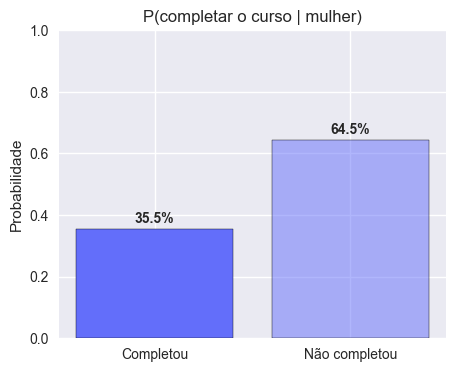

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Filtrar apenas mulheres ---
df_f = df_students_performance[df_students_performance["gender"] == "female"].copy()

# Transformar em binária
df_f["completed_bin"] = (df_f["test preparation course"] == "completed").astype(int)

# Calcular probabilidade condicional
P_completed_given_woman = df_f["completed_bin"].mean()

print(f"P(completar | mulher) = {P_completed_given_woman:.2%}")

# --- Gráfico simples ---
plt.figure(figsize=(5,4))

labels = ["Completou", "Não completou"]
values = [
    P_completed_given_woman,
    1 - P_completed_given_woman
]

colors = ["#636EFA", "#636EFA80"]  # azul + azul claro

bars = plt.bar(labels, values, color=colors, edgecolor='black')

# rótulo
for bar, v in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, v + 0.02, f"{v:.1%}",
             ha='center', fontsize=10, fontweight='bold')

plt.ylim(0, 1)
plt.ylabel("Probabilidade")
plt.title("P(completar o curso | mulher)")
plt.show()

### Teorema de Bayes

Qual é a probabilidade de um estudante ser mulher, dado que completou o curso preparatório?

In [ ]:
# Eventos:
# A = ser mulher
# B = ter completado o curso preparatório

# P(A): probabilidade de ser mulher
P_A = len(df_students_performance[df_students_performance["gender"] == "female"]) / len(df_students_performance)

# P(B): probabilidade de ter completado o curso preparatório
P_B = len(df_students_performance[df_students_performance["test preparation course"] == "completed"]) / len(df_students_performance)

# P(B|A): probabilidade de completar o curso dado que é mulher
mulheres = df_students_performance[df_students_performance["gender"] == "female"]
P_B_dado_A = len(mulheres[mulheres["test preparation course"] == "completed"]) / len(mulheres)

# Teorema de Bayes: P(A|B)
P_A_dado_B = (P_B_dado_A * P_A) / P_B

print(f"Probabilidade de ser mulher é de {round(P_A*100,2)}%")
print(f"Probabilidade de ter completado o curso preparatório é de {round(P_B*100,2)}%")
print(f"Probabilidade de completar o curso dado que é mulher é de {round(P_B_dado_A*100,2)}%")
print(f"Probabilidade de ser mulher dado que completou o curso é de {round(P_A_dado_B*100,2)}%")


Probabilidade de ser mulher é de 51.8%
Probabilidade de ter completado o curso preparatório é de 35.8%
Probabilidade de completar o curso dado que é mulher é de 35.52%
Probabilidade de ser mulher dado que completou o curso é de 51.4%


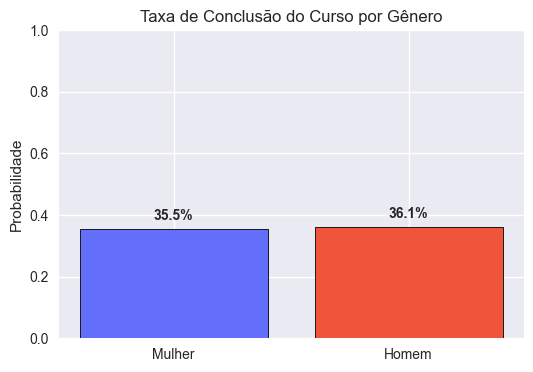

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Copie seu DataFrame original
df = df_students_performance.copy()

# Padroniza rótulos
df['gender'] = df['gender'].str.lower().map({'female': 'Mulher', 'male': 'Homem'})
df['test preparation course'] = df['test preparation course'].str.lower().map(
    {'completed': 'Completou', 'none': 'Não completou'}
)

# Tabela de contingência (gênero x conclusão)
ct = pd.crosstab(df['gender'], df['test preparation course']).reindex(['Mulher', 'Homem'])

# Taxa de conclusão por gênero: P(completar | gênero)
P_completed_given_woman = ct.loc['Mulher', 'Completou'] / ct.loc['Mulher'].sum()
P_completed_given_man   = ct.loc['Homem',  'Completou'] / ct.loc['Homem'].sum()

# Cores iguais ao seu boxplot (Plotly)
COLOR_WOMAN = '#636EFA'  # azul
COLOR_MAN   = '#EF553B'  # vermelho

# Plot
plt.figure(figsize=(6,4))
labels = ['Mulher', 'Homem']
values = [P_completed_given_woman, P_completed_given_man]
colors = [COLOR_WOMAN, COLOR_MAN]

bars = plt.bar(labels, values, color=colors, edgecolor='black', linewidth=0.6)
plt.ylabel('Probabilidade')
plt.title('Taxa de Conclusão do Curso por Gênero')
plt.ylim(0, 1)

# Rótulos de porcentagem acima das barras
for bar, v in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.1%}',
             ha='center', va='bottom', fontweight='bold')

plt.show()

# Variáveis Aleatórias

### Variáveis Aleatórias

Variável aleatória (X) será a média das notas

In [ ]:
#Criando a variável MadiaNotas, que será a média de cada aluno que tem as três notas: Matemática, Leitura, Escrita.
df_students_performance["MediaNotas"] = (
    df_students_performance["math score"] +
    df_students_performance["reading score"] +
    df_students_performance["writing score"]
) / 3

df_students_performance.head(10)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,MediaNotas
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333
5,female,group B,associate's degree,standard,none,71,83,78,77.333333
6,female,group B,some college,standard,completed,88,95,92,91.666667
7,male,group B,some college,free/reduced,none,40,43,39,40.666667
8,male,group D,high school,free/reduced,completed,64,64,67,65.000000
9,female,group B,high school,free/reduced,none,38,60,50,49.333333


In [ ]:
#conta quantas vezes cada valor da variável “MediaNotas” aparece no dataset,e depois ordena os valores em ordem crescente.
df_students_performance["MediaNotas"].value_counts().sort_index()  

MediaNotas
9.000000      1
18.333333     1
23.000000     1
23.333333     1
26.000000     2
             ..
97.666667     3
98.666667     2
99.000000     2
99.666667     1
100.000000    3
Name: count, Length: 194, dtype: int64

### Função Probabilidade

In [ ]:
# Criar um função probabilidade
fp = df_students_performance["MediaNotas"].value_counts().sort_index()/len(df_students_performance)
print(fp)

MediaNotas
9.000000      0.001
18.333333     0.001
23.000000     0.001
23.333333     0.001
26.000000     0.002
              ...  
97.666667     0.003
98.666667     0.002
99.000000     0.002
99.666667     0.001
100.000000    0.003
Name: count, Length: 194, dtype: float64


### Função Repartição (Cumulativa)

É usado para descrever a distribuição de uma variável aleatória

- Acumula probabilidades até o valor 𝑥

- Sempre cresce (nunca diminui)

- Vai de 0 a 1

- Permite calcular probabilidades em intervalos: P(a≤X≤b)=F(b)−F(a)

In [ ]:
fp.cumsum()

MediaNotas
9.000000      0.001
18.333333     0.002
23.000000     0.003
23.333333     0.004
26.000000     0.006
              ...  
97.666667     0.992
98.666667     0.994
99.000000     0.996
99.666667     0.997
100.000000    1.000
Name: count, Length: 194, dtype: float64

Text(0.5, 1.0, 'Função de Repartição – Nota de Matemática')

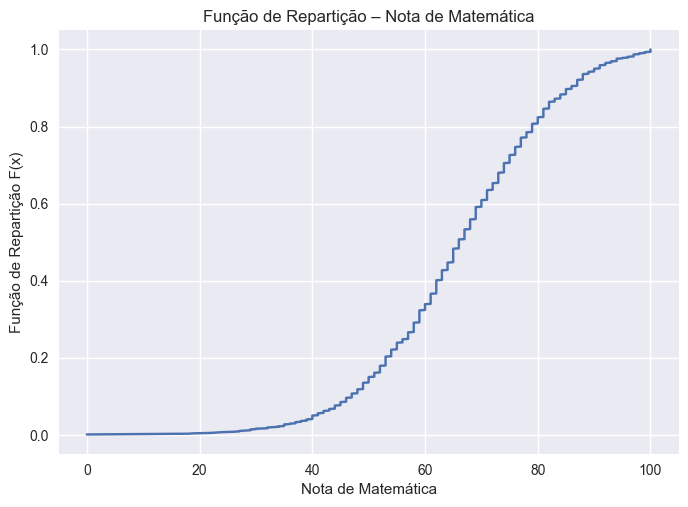

In [ ]:
# Escolha da variável (nota de matemática)
data = df_students_performance['math score'].sort_values()

# Função de repartição empírica (CDF)
cdf = data.rank(method='first') / len(data)

# Gráfico
plt.figure()
plt.plot(data, cdf)
plt.xlabel('Nota de Matemática')
plt.ylabel('Função de Repartição F(x)')
plt.title('Função de Repartição – Nota de Matemática')

# Estatística Descritiva

### Gráficos Simples

### Box Plot

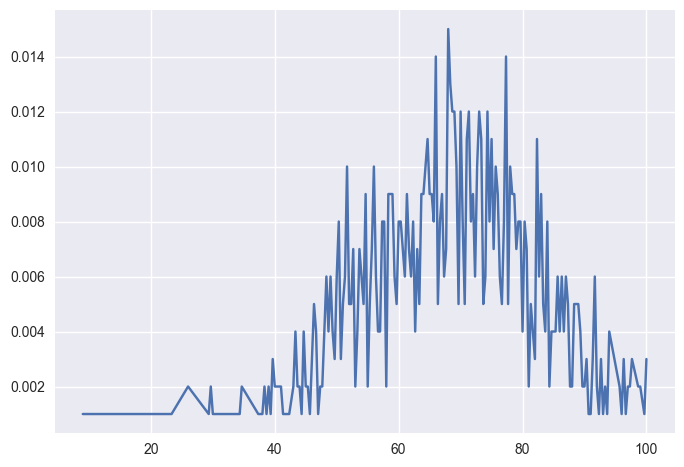

In [ ]:
plt.plot(fp)

### Histograma

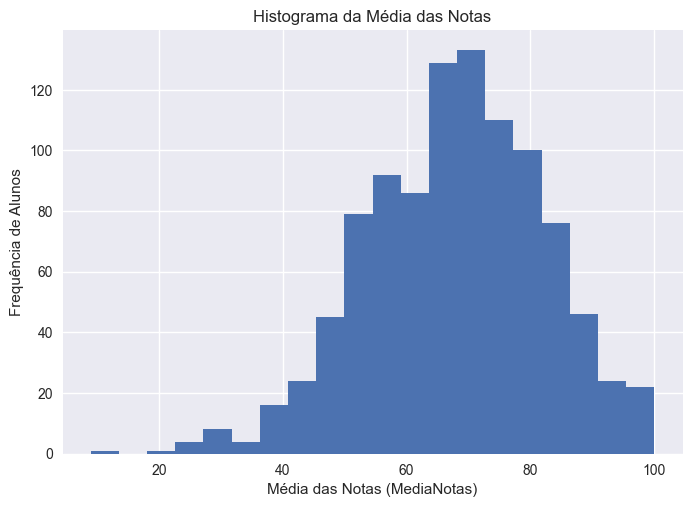

In [ ]:
plt.hist(df_students_performance["MediaNotas"], bins=20)
plt.xlabel("Média das Notas (MediaNotas)")
plt.ylabel("Frequência de Alunos")
plt.title("Histograma da Média das Notas")
plt.show()

Text(0.5, 1.0, 'Função de Distribuição Acumulada (CDF) da Média das Notas')

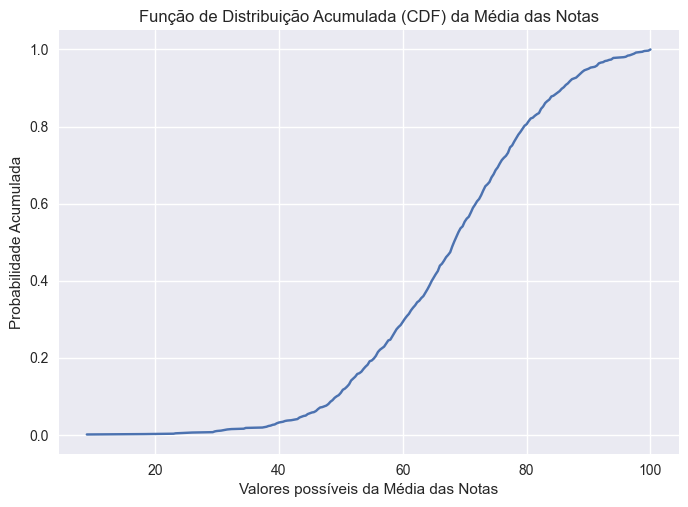

In [ ]:
graficoacumulado = fp.cumsum()
plt.plot(graficoacumulado)
plt.xlabel('Valores possíveis da Média das Notas')
plt.ylabel('Probabilidade Acumulada')
plt.title('Função de Distribuição Acumulada (CDF) da Média das Notas')

### Gráfico de comparação de Generos

In [ ]:
fig = px.box(
    df_students_performance,
    x='gender',
    y='math score',
    color='gender'
)
fig.show()

Mostra que os homens costumam ter a mediana um pouco maior em matemática… Não é uma diferença absurda, mas é consistente!

In [ ]:
fig2 = px.histogram(
    df_students_performance,
    x='reading score',
    marginal='box'
)
fig2.show()

A maioria dos alunos apresenta notas de leitura concentradas na faixa intermediária, com poucos valores extremos, o que indica um desempenho geral estável nessa disciplina

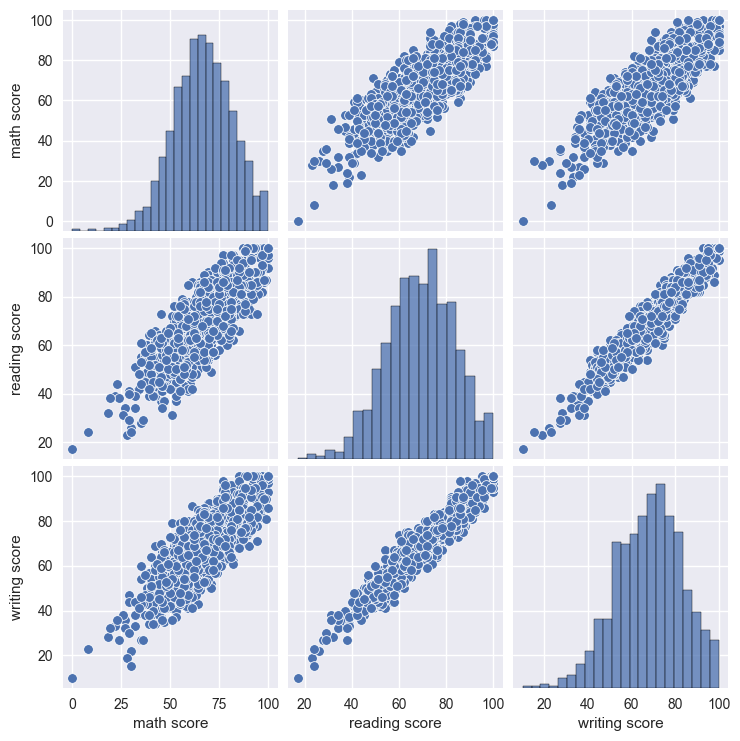

In [ ]:
col = ['math score', 'reading score', 'writing score']
sns.pairplot(df_students_performance[col])

O pairplot indica uma correlação positiva entre as três disciplinas, com destaque para a forte relação entre leitura e escrita. Esse padrão sugere que alunos com bom desempenho em leitura tendem também a obter boas notas em escrita.

 ### Scatter plot

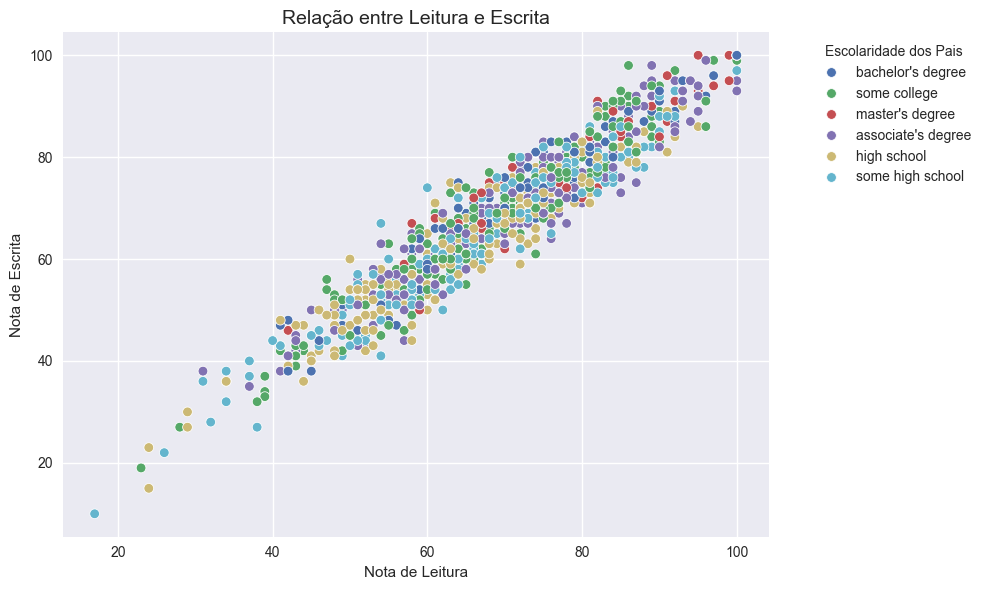

In [ ]:

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x='reading score', 
    y='writing score', 
    data=df_students_performance, 
    hue='parental level of education'
)

plt.title('Relação entre Leitura e Escrita', fontsize=14)
plt.xlabel('Nota de Leitura')
plt.ylabel('Nota de Escrita')

plt.legend(title='Escolaridade dos Pais', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Variável Aleatórias Contínuas

Variável aleatória contínua mede grandezas que variam de forma contínua, e suas probabilidades vêm da área sob a curva da função densidade.

- Assume valores contínuos

- A probabilidade em um ponto exato é zero: P(X=x)=0

- As probabilidades são calculadas em intervalos

- São descritas por uma função densidade de probabilidade f(x)

- A função de repartição é a integral da densidade




Exemplo para Variáveis Aleatórias Contínuas

In [ ]:
np.random.seed(42)
data = np.random.normal(loc=50, scale=10, size=1000)

df = pd.DataFrame(data, columns=['Valores'])
print(df)
print(df['Valores'].min())
print(df['Valores'].max())

       Valores
0    54.967142
1    48.617357
2    56.476885
3    65.230299
4    47.658466
..         ...
995  47.188997
996  67.976865
997  56.408429
998  44.288210
999  55.725828

[1000 rows x 1 columns]
17.58732659930927
88.52731490654722


Calcular a probabilidade de que um valor da distribuição normal esteja entre 50 e 60.

In [ ]:
lower_bound= 50
upper_bound = 60

mean = df['Valores'].mean()
std_dev = df['Valores'].std()

x = norm.cdf(upper_bound, loc=mean, scale=std_dev)
y = norm.cdf(lower_bound, loc=mean, scale=std_dev)

probabilidade = x-y
print(f'A probabilidade de estar entre {lower_bound} e {upper_bound} é de {round(probabilidade*100,2)}%')

A probabilidade de estar entre 50 e 60 é de 34.96%


### Covariância

Covariância mede como duas variáveis aleatórias variam juntas

- Indica a relação linear entre duas variáveis

- Pode ser positiva, negativa ou zero

    - Positiva: crescem juntas

    - Negativa: uma cresce e a outra diminui

    - Zero: não há relação linear




In [ ]:

# Seleção das colunas numéricas de interesse
num_cols = ['reading score', 'writing score']
X = df_students_performance[num_cols].copy()

# Matriz de covariância
cov_matrix = X.cov()

cov_matrix


,reading score,writing score
reading score,213.165605,211.786661
writing score,211.786661,230.907992


### Heatmap da Covariância

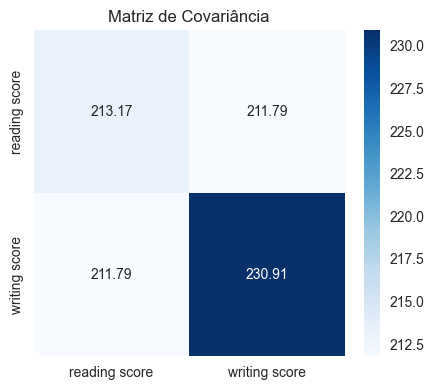

In [ ]:
# Heatmap da Covariância
fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(cov_matrix, annot=True, fmt='.2f', cmap='Blues', cbar=True, ax=ax)
ax.set_title('Matriz de Covariância')
fig.tight_layout()



- A covariância positiva sugere que leitura e escrita estão correlacionadas positivamente.

- Quanto maior a covariância, mais forte é essa relação linear.

### Correlação

Indica como duas variáveis se relacionam, ou seja, se elas variam juntas e em que direção.

A correlação mostra se, quando uma variável aumenta, a outra:

- também aumenta

- diminui

- ou não muda de forma previsível

 Intervalo : [-1, +1]

+1 → correlação positiva perfeita (as variáveis aumentam juntas de forma linear).

-1 → correlação negativa perfeita (uma aumenta enquanto a outra diminui, linearmente).

0 → nenhuma correlação linear (não há relação linear clara).

In [ ]:
# Matriz de correlação (Pearson)
corr_matrix = X.corr(method='pearson')

corr_matrix

,reading score,writing score
reading score,1.000000,0.954598
writing score,0.954598,1.000000


### Heatmap da Correlação (Pearson)

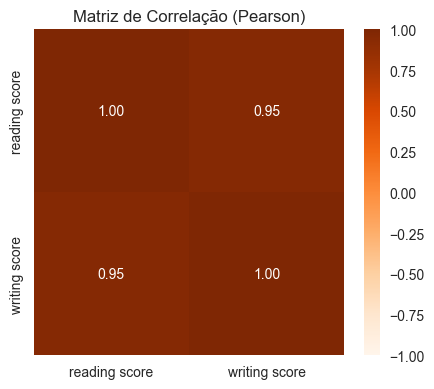

In [ ]:
# Heatmap da Correlação (Pearson)
fig2, ax2 = plt.subplots(figsize=(4.5, 4))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Oranges', vmin=-1, vmax=1, cbar=True, ax=ax2)
ax2.set_title('Matriz de Correlação (Pearson)')
fig2.tight_layout()


Interpretação prática: estudantes com notas altas em leitura tendem fortemente a ter notas altas em escrita; melhorias em uma provavelmente se refletem na outra.

### Tratamento de Dados

In [ ]:
df_students_performance.head(10)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,MediaNotas
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333
5,female,group B,associate's degree,standard,none,71,83,78,77.333333
6,female,group B,some college,standard,completed,88,95,92,91.666667
7,male,group B,some college,free/reduced,none,40,43,39,40.666667
8,male,group D,high school,free/reduced,completed,64,64,67,65.000000
9,female,group B,high school,free/reduced,none,38,60,50,49.333333


In [ ]:
df_students_performance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       1000 non-null   object 
 1   race/ethnicity               1000 non-null   object 
 2   parental level of education  1000 non-null   object 
 3   lunch                        1000 non-null   object 
 4   test preparation course      1000 non-null   object 
 5   math score                   1000 non-null   int64  
 6   reading score                1000 non-null   int64  
 7   writing score                1000 non-null   int64  
 8   MediaNotas                   1000 non-null   float64
dtypes: float64(1), int64(3), object(5)
memory usage: 70.4+ KB


In [ ]:
df_students_performance.describe()

,math score,reading score,writing score,MediaNotas
count,1000.00000,1000.000000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000,67.770667
std,15.16308,14.600192,15.195657,14.257326
min,0.00000,17.000000,10.000000,9.000000
25%,57.00000,59.000000,57.750000,58.333333
50%,66.00000,70.000000,69.000000,68.333333
75%,77.00000,79.000000,79.000000,77.666667
max,100.00000,100.000000,100.000000,100.000000


<Axes: >

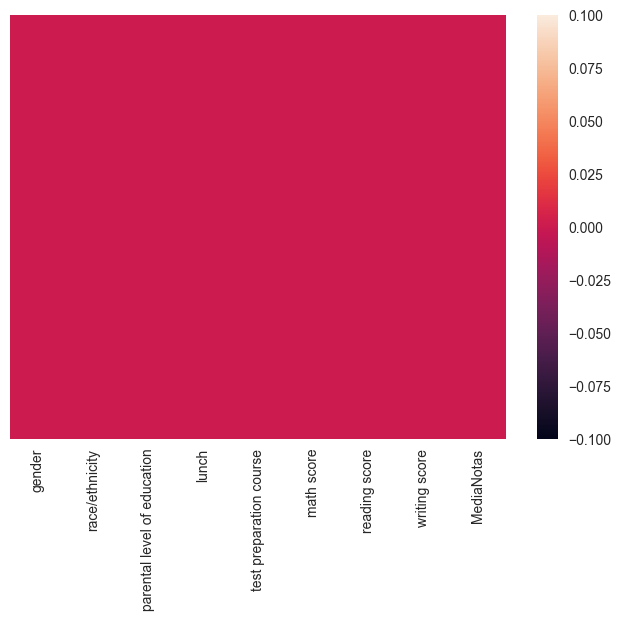

In [ ]:
# Mostra que em todoas as colunas não tem valores nulos. Ou seja, dataset não tem dados faltantes.

sns.heatmap(df_students_performance.isnull(), yticklabels=False) 

#### Dummy encoding ou Codificação one-hot

In [ ]:
# dummy encoding ou codificação one-hot: no qual Cada coluna representa uma categoria única, em binário (0 ou 1)
nivel_educacional_parentes = pd.get_dummies(df_students_performance['parental level of education'], dtype=int)
nivel_educacional_parentes.head()

,associate's degree,bachelor's degree,high school,master's degree,some college,some high school
0,0,1,0,0,0,0
1,0,0,0,0,1,0
2,0,0,0,1,0,0
3,1,0,0,0,0,0
4,0,0,0,0,1,0


In [ ]:
sexo = pd.get_dummies(df_students_performance['gender'],dtype=int)
sexo.head()

,female,male
0,1,0
1,1,0
2,1,0
3,0,1
4,0,1


In [ ]:
df_students_performance = pd.concat([df_students_performance, nivel_educacional_parentes, sexo], axis=1)
df_students_performance.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,MediaNotas,associate's degree,bachelor's degree,high school,master's degree,some college,some high school,female,male
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667,0,1,0,0,0,0,1,0
1,female,group C,some college,standard,completed,69,90,88,82.333333,0,0,0,0,1,0,1,0
2,female,group B,master's degree,standard,none,90,95,93,92.666667,0,0,0,1,0,0,1,0
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333,1,0,0,0,0,0,0,1
4,male,group C,some college,standard,none,76,78,75,76.333333,0,0,0,0,1,0,0,1


### Distribuição de Probabilidade

KDE: É uma técnica estatística para estimar a função de densidade de probabilidade de uma variável contínua.
Em vez de mostrar apenas um histograma (que depende do tamanho das classes), o KDE cria uma curva suave que indica onde os dados se concentram.

In [ ]:

df_students_performance.columns = (
    df_students_performance.columns
        .str.strip().str.lower()
        .str.replace(r'[\\/]+', '_', regex=True)
        .str.replace(r'\s+', '_', regex=True)
)

col_math     = 'math_score'
col_read     = 'reading_score'
col_write    = 'writing_score'
col_testprep = 'test_preparation_course'
col_race     = 'race_ethnicity'


def show_hist_kde_normal(series, title):
    """Histograma + KDE + Curva Normal ajustada, com estatísticas e testes."""
    x = pd.to_numeric(series, errors='coerce').dropna().astype(float)
    mu, sigma = x.mean(), x.std(ddof=1)
    skew, kurt = stats.skew(x), stats.kurtosis(x, fisher=True)
    ks_stat, ks_p = stats.kstest(x, 'norm', args=(mu, sigma))
    sh_sample = x.sample(min(500, len(x)), random_state=42)
    sh_stat, sh_p = stats.shapiro(sh_sample)
    ad = stats.anderson(x, dist='norm')
    ad_cv5 = ad.critical_values[2]
    ad_reject5 = ad.statistic > ad_cv5

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.hist(x, bins=20, density=True, color='#4C78A8', edgecolor='white', alpha=0.85)
    try:
        kde = stats.gaussian_kde(x)
        grid = np.linspace(x.min(), x.max(), 200)
        ax.plot(grid, kde(grid), color='#2E93FA', lw=2, label='KDE')
    except Exception:
        grid = np.linspace(x.min(), x.max(), 200)
    ax.plot(grid, stats.norm.pdf(grid, mu, sigma), color='#E45756', lw=2,
            label=f'Normal(mu={mu:.2f}, sd={sigma:.2f})')

    ax.set_title(title)
    ax.set_xlabel('Pontuação'); ax.set_ylabel('Densidade')
    ax.legend(loc='upper left')
    plt.show()


def show_bernoulli(series, title):
    """Barplot para variável dicotômica: none vs completed."""
    x = series.dropna().astype(str).str.strip().str.lower()
    x = x.replace({'completed ': 'completed', ' none': 'none'})
    counts = x.value_counts()
    order = [c for c in ['none', 'completed'] if c in counts.index]
    p_completed = counts.get('completed', 0) / counts.sum()

    fig, ax = plt.subplots(figsize=(7, 4.5))
    bars = [counts.get(cat, 0) for cat in order]
    colors = ['#72B7B2' if cat == 'none' else '#E45756' for cat in order]
    ax.bar(order, bars, color=colors)
    ax.set_title(title); ax.set_xlabel('Categoria'); ax.set_ylabel('Frequência')
    ax.text(0.98, 0.98, f"p (completed) ~ {p_completed:.3f}",
            transform=ax.transAxes, va='top', ha='right', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    plt.show()

print("[OK] Setup executado. Funções definidas e colunas mapeadas.")

df_students_performance.head()


[OK] Setup executado. Funções definidas e colunas mapeadas.


,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,medianotas,associate's_degree,bachelor's_degree,high_school,master's_degree,some_college,some_high_school,female,male
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667,0,1,0,0,0,0,1,0
1,female,group C,some college,standard,completed,69,90,88,82.333333,0,0,0,0,1,0,1,0
2,female,group B,master's degree,standard,none,90,95,93,92.666667,0,0,0,1,0,0,1,0
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333,1,0,0,0,0,0,0,1
4,male,group C,some college,standard,none,76,78,75,76.333333,0,0,0,0,1,0,0,1


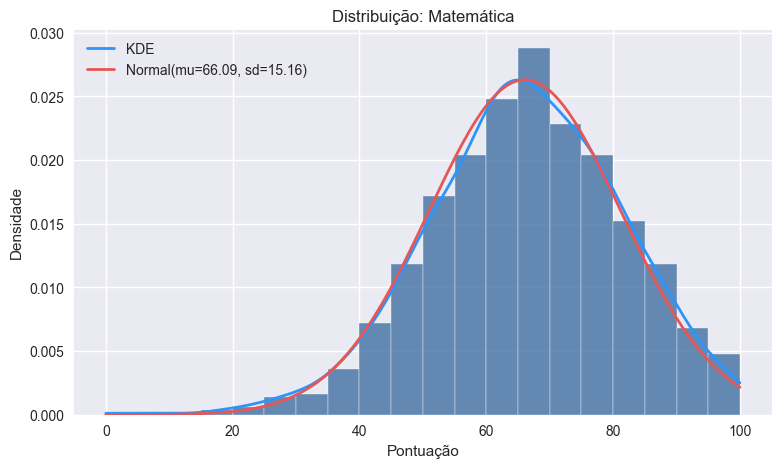

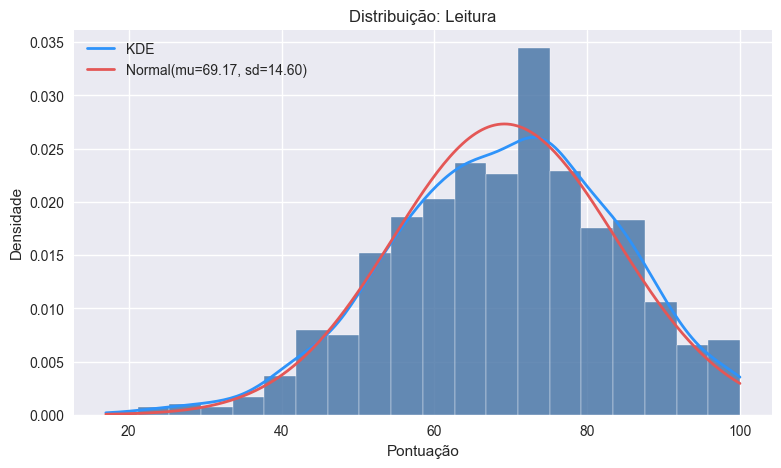

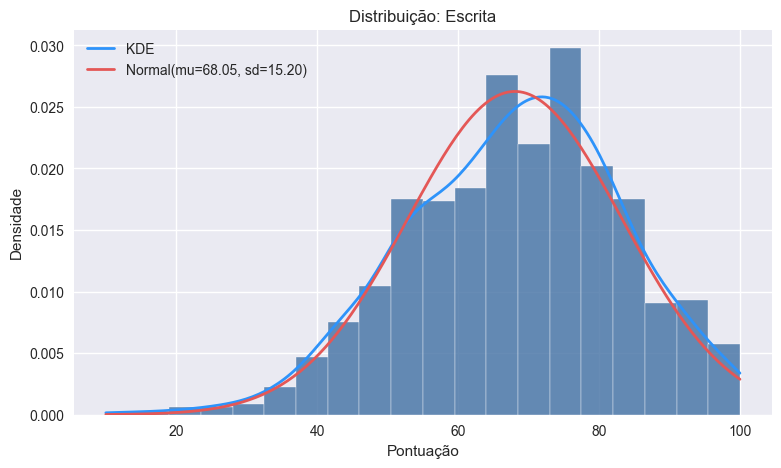

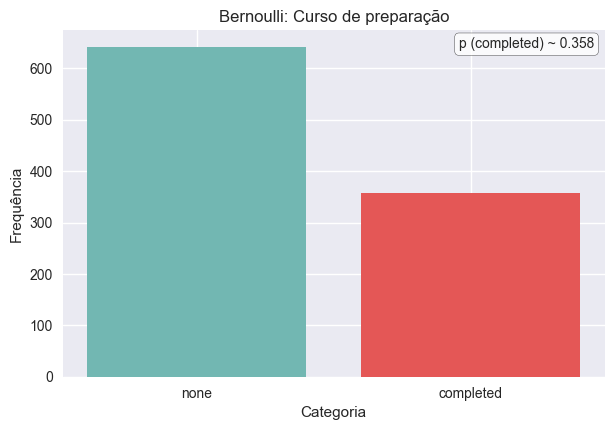

In [ ]:

# Matemática
show_hist_kde_normal(df_students_performance[col_math], 'Distribuição: Matemática')

# Leitura
show_hist_kde_normal(df_students_performance[col_read], 'Distribuição: Leitura')

# Escrita (opcional)
show_hist_kde_normal(df_students_performance[col_write], 'Distribuição: Escrita')

# Bernoulli: curso de preparação
show_bernoulli(df_students_performance[col_testprep], 'Bernoulli: Curso de preparação')


### Distribuições Amostrais

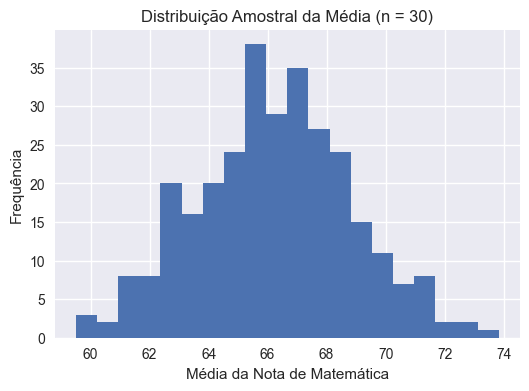

In [ ]:
# Gráfico simples
plt.figure(figsize=(6,4))
plt.hist(sample_means, bins=20)
plt.xlabel('Média da Nota de Matemática')
plt.ylabel('Frequência')
plt.title('Distribuição Amostral da Média (n = 30)')
plt.show()

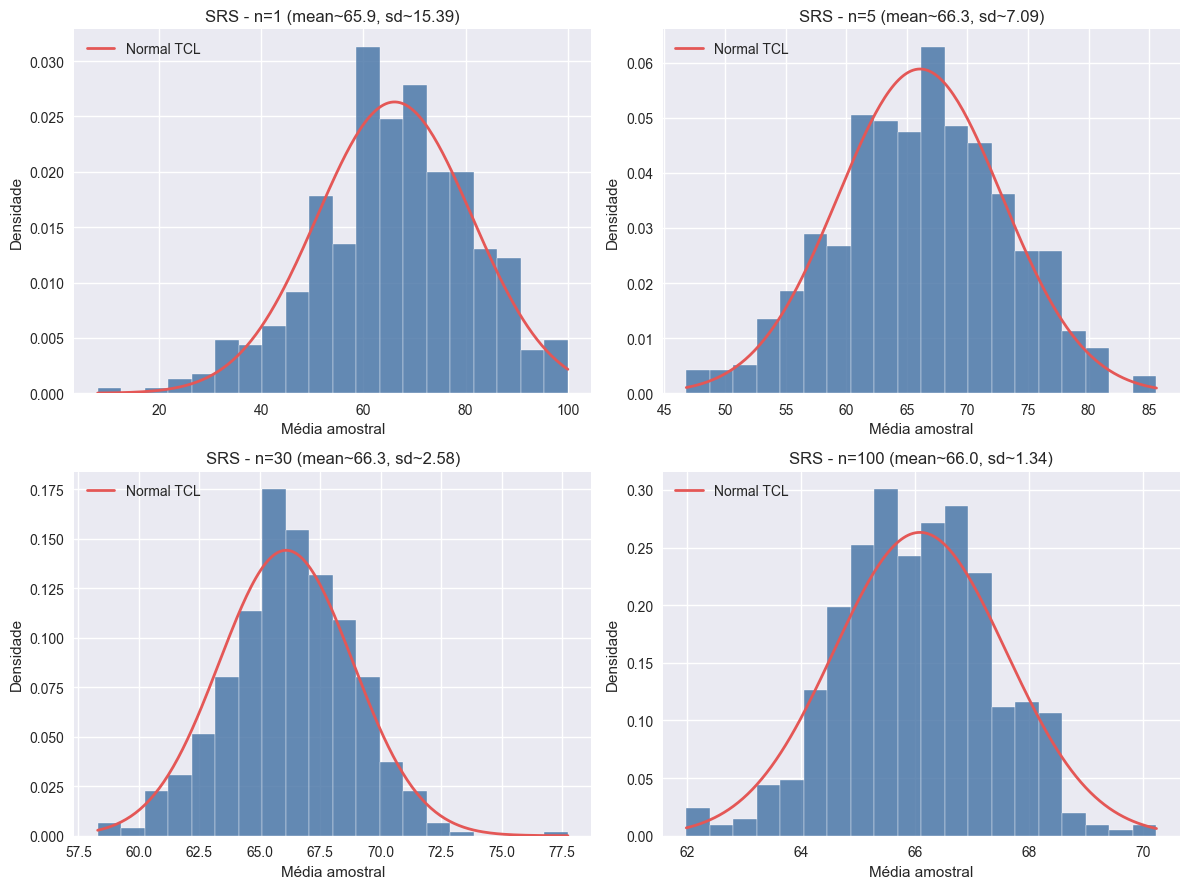

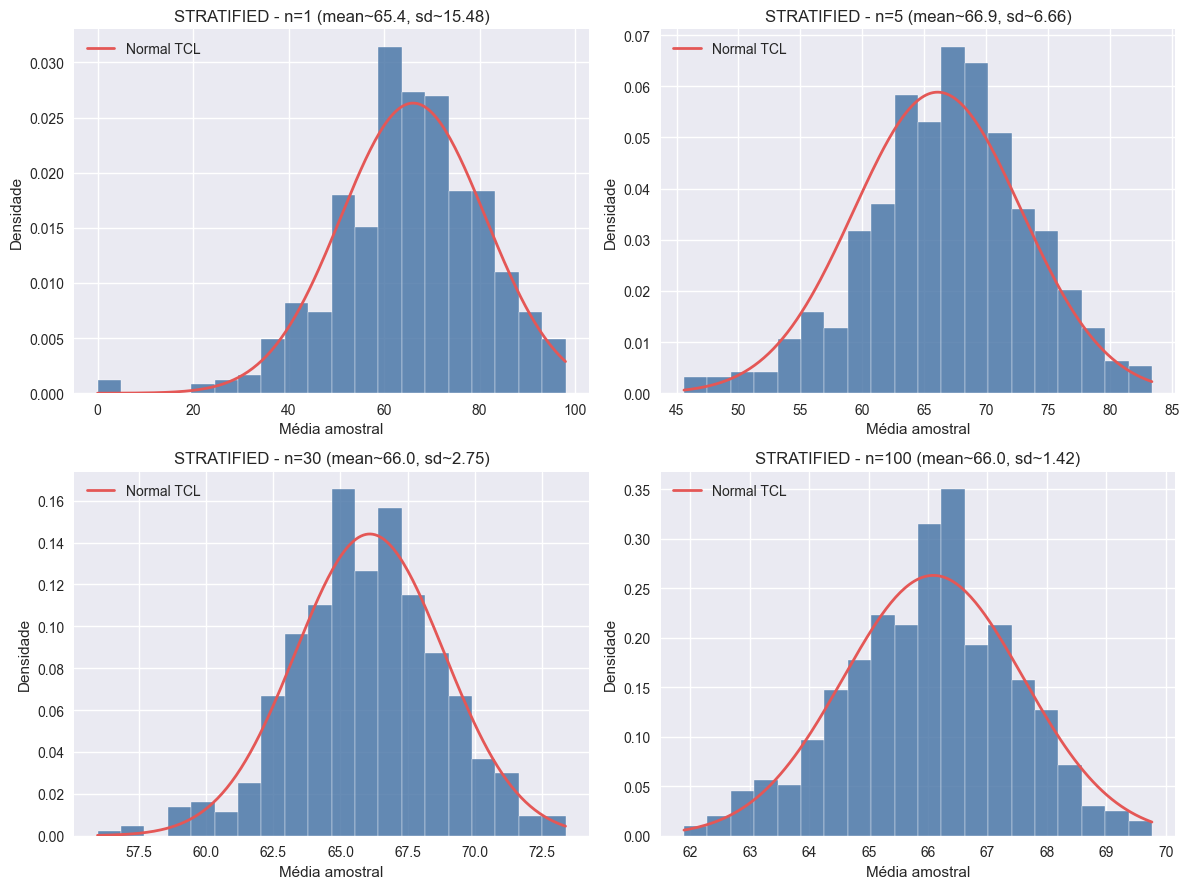

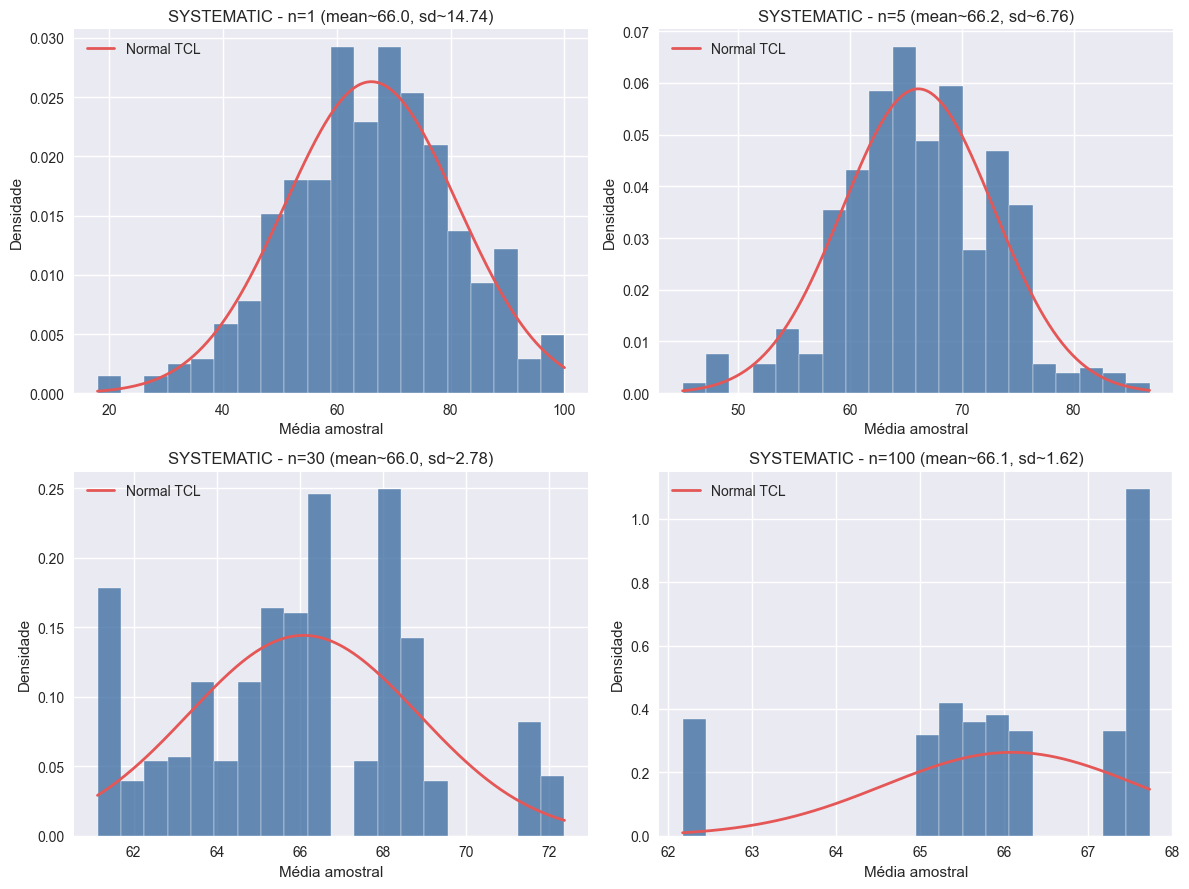

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

# População em Matemática
x_pop = pd.to_numeric(df_students_performance[col_math], errors='coerce').dropna().astype(float).values
N = len(x_pop)

# Estratificação por raça/etnia
df_strata = df_students_performance[[col_race, col_math]].dropna().copy()
strata_counts = df_strata[col_race].value_counts()
strata_names = strata_counts.index.tolist()
strata_indices = {name: df_strata[df_strata[col_race] == name].index.values
                  for name in strata_names}

def sample_means(method, n, reps=500):
    means = []
    if method == 'srs':  # aleatória simples
        for _ in range(reps):
            idx = np.random.choice(np.arange(N), size=n, replace=False)
            means.append(x_pop[idx].mean())

    elif method == 'stratified':  # proporcional aos estratos
        alloc = {s: int(round(n * strata_counts[s] / strata_counts.sum())) for s in strata_names}
        while sum(alloc.values()) < n:
            residuals = {s: (n * strata_counts[s] / strata_counts.sum()) - alloc[s] for s in strata_names}
            s_add = max(residuals, key=residuals.get); alloc[s_add] += 1
        while sum(alloc.values()) > n:
            s_sub = max(alloc, key=alloc.get); alloc[s_sub] -= 1
        for _ in range(reps):
            sample_vals = []
            for s in strata_names:
                idx_s = np.random.choice(strata_indices[s], size=alloc[s], replace=False)
                sample_vals.extend(df_students_performance.loc[idx_s, col_math].astype(float).tolist())
            means.append(np.mean(sample_vals))

    elif method == 'systematic':
        perm = np.random.permutation(N)
        k = max(1, N // n)
        for _ in range(reps):
            start = np.random.randint(0, k)
            idx = perm[start::k][:n]
            means.append(x_pop[idx].mean())
    else:
        raise ValueError('Metodo desconhecido')
    return np.array(means)

ns = [1, 5, 30, 100]

def show_sampling_panels(method):
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    mu_pop = x_pop.mean()
    sd_pop = x_pop.std(ddof=1)

    for i, n in enumerate(ns):
        means = sample_means(method, n, reps=500)
        ax = axes[i // 2, i % 2]
        ax.hist(means, bins=20, density=True, color='#4C78A8', edgecolor='white', alpha=0.85)
        grid = np.linspace(means.min(), means.max(), 200)
        ax.plot(grid, stats.norm.pdf(grid, mu_pop, sd_pop / np.sqrt(n)),
                color='#E45756', lw=2, label='Normal TCL')
        title = f"{method.upper()} - n={n} (mean~{means.mean():.1f}, sd~{means.std(ddof=1):.2f})"
        ax.set_title(title)
        ax.set_xlabel('Média amostral')
        ax.set_ylabel('Densidade')
        ax.legend(loc='upper left')

    fig.tight_layout()
    plt.show()

# Mostrar os três painéis
show_sampling_panels('srs')
show_sampling_panels('stratified')
show_sampling_panels('systematic')


### Normalização dos Dados (Padronização)

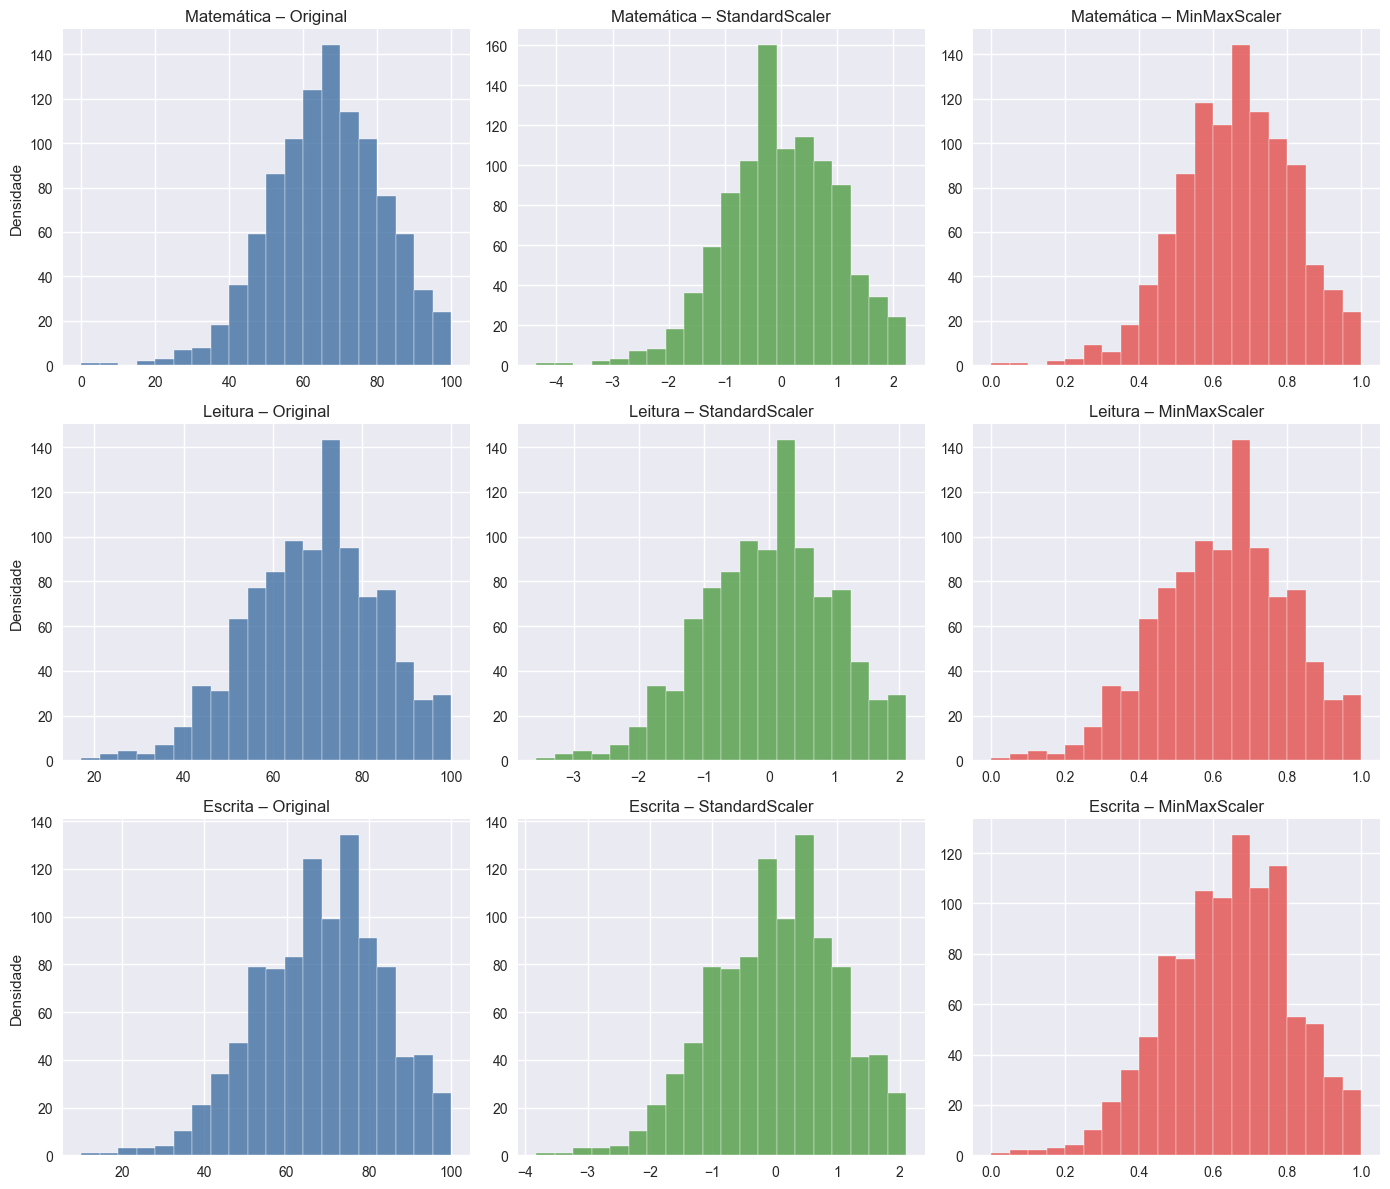

C:\Users\melos\AppData\Local\Temp\ipykernel_24688\769851406.py:35: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.

C:\Users\melos\AppData\Local\Temp\ipykernel_24688\769851406.py:36: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.

C:\Users\melos\AppData\Local\Temp\ipykernel_24688\769851406.py:37: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



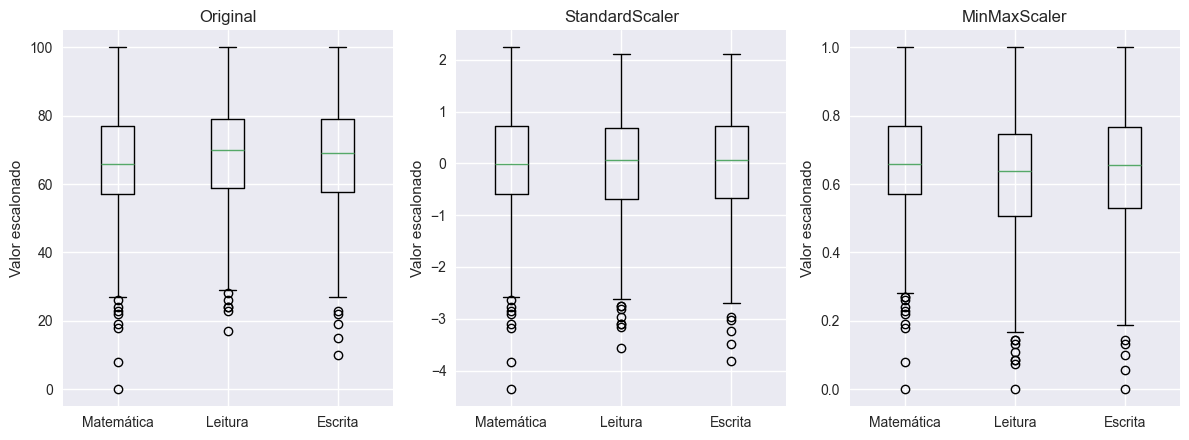

In [ ]:
# StandardScaler vs MinMaxScaler com df_students_performance
try:
    from sklearn.preprocessing import StandardScaler, MinMaxScaler
    use_fallback = False
except Exception:
    use_fallback = True

X = df_students_performance[[col_math, col_read, col_write]].dropna().astype(float).values
feat_names = ['Matemática', 'Leitura', 'Escrita']

if not use_fallback:
    X_std = StandardScaler().fit_transform(X)
    X_mm  = MinMaxScaler(feature_range=(0, 1)).fit_transform(X)
else:
    mu = X.mean(axis=0); sigma = X.std(axis=0, ddof=1)
    X_std = (X - mu) / sigma
    xmin = X.min(axis=0); xmax = X.max(axis=0)
    X_mm  = (X - xmin) / (xmax - xmin)

# Painel de histogramas
fig, axes = plt.subplots(3, 3, figsize=(14, 12))
titles = ['Original', 'StandardScaler', 'MinMaxScaler']
for i in range(3):
    datasets = [X[:, i], X_std[:, i], X_mm[:, i]]
    for j in range(3):
        ax = axes[i, j]
        ax.hist(datasets[j], bins=20, color=['#4C78A8','#59A14F','#E45756'][j],
                edgecolor='white', alpha=0.85)
        ax.set_title(f"{feat_names[i]} – {titles[j]}")
        ax.set_ylabel('Densidade' if j==0 else '')
plt.tight_layout(); plt.show()

# Boxplots comparativos
fig, axes = plt.subplots(1, 3, figsize=(12, 4.5))
axes[0].boxplot([X[:,0], X[:,1], X[:,2]], labels=feat_names); axes[0].set_title('Original')
axes[1].boxplot([X_std[:,0], X_std[:,1], X_std[:,2]], labels=feat_names); axes[1].set_title('StandardScaler')
axes[2].boxplot([X_mm[:,0], X_mm[:,1], X_mm[:,2]], labels=feat_names); axes[2].set_title('MinMaxScaler')
for ax in axes: ax.set_ylabel('Valor escalonado')
plt.tight_layout(); plt.show()

Interpretação

- StandardScaler (μ≈0, σ≈1) é adequado para algoritmos que assumem dados centrados/normalizados (ex.: regressão logística, SVM com kernel linear).

- MinMaxScaler ([0,1]) é indicado quando distâncias importam (ex.: KNN, redes neurais) ou quando limites são exigidos.

- As variáveis escolhidas (notas de Matemática, Leitura, Escrita) são contínuas e típicas em cenários de classificação (apto a modelos supervisio